# UrbanHeat AI: Al Khor city study

Team Al Zubarah (الزبارة), Qatar. Theme: Urban Expansion, Land Use Change & Heat Risk.

The analyst-defined city window includes coastal and desert context. It is not an official boundary. Urban candidate cells are screened using historical built-up land or contributed building geometry.

Run all cells from the repository root. Included source crops allow offline analysis.

In [1]:
from pathlib import Path
import runpy, json, contextlib, io
from IPython.display import display, Image
ROOT = Path.cwd()
assert (ROOT / "src/export_map.py").exists(), "Open this notebook from the repository root."
assert (ROOT / "data/sample_input/reference/worldcover2021.tif").exists()

## Sources and screening

Sentinel-2: 5, 15 and 30 September 2026. Landsat: 6, 14 and 30 September 2026. Date acceptance requires at least 50% quality coverage of historical urban inland support, before comparing temperatures. WorldCover describes 2021; OSM was downloaded 5 October 2026.

Require persistent clear optical land, a 60 m water buffer and crop halo, at least 90% inland support, ST_QA ≤2 K, cloud distance ≥1 km and valid QA. A 300 m cell requires 25 delivered 30 m samples, which are spatially dependent. Thermal detail remains about 100 m.
Historical WorldCover water, herbaceous wetland and mangrove classes are also buffered out conservatively. They are not treated as current truth.


In [2]:
with contextlib.redirect_stdout(io.StringIO()):
    pipeline = runpy.run_path(str(ROOT / "src/export_map.py"))
planning = pipeline["planning"]["report"]
summary = pipeline["data"]["report"]
print(f"Common footprint: {planning['common_footprint_km2']:.2f} km²")
print(f"Reported cells: {planning['reported_cells']}")
print("Thermal dates:", ", ".join(summary["accepted_thermal_dates"]))
print("First investigation candidates:", ", ".join(p["cell_id"] for p in planning["top3"]))

Common footprint: 94.44 km²
Reported cells: 373
Thermal dates: 2026-09-14, 2026-09-30
First investigation candidates: V04-23, V28-17, V04-24


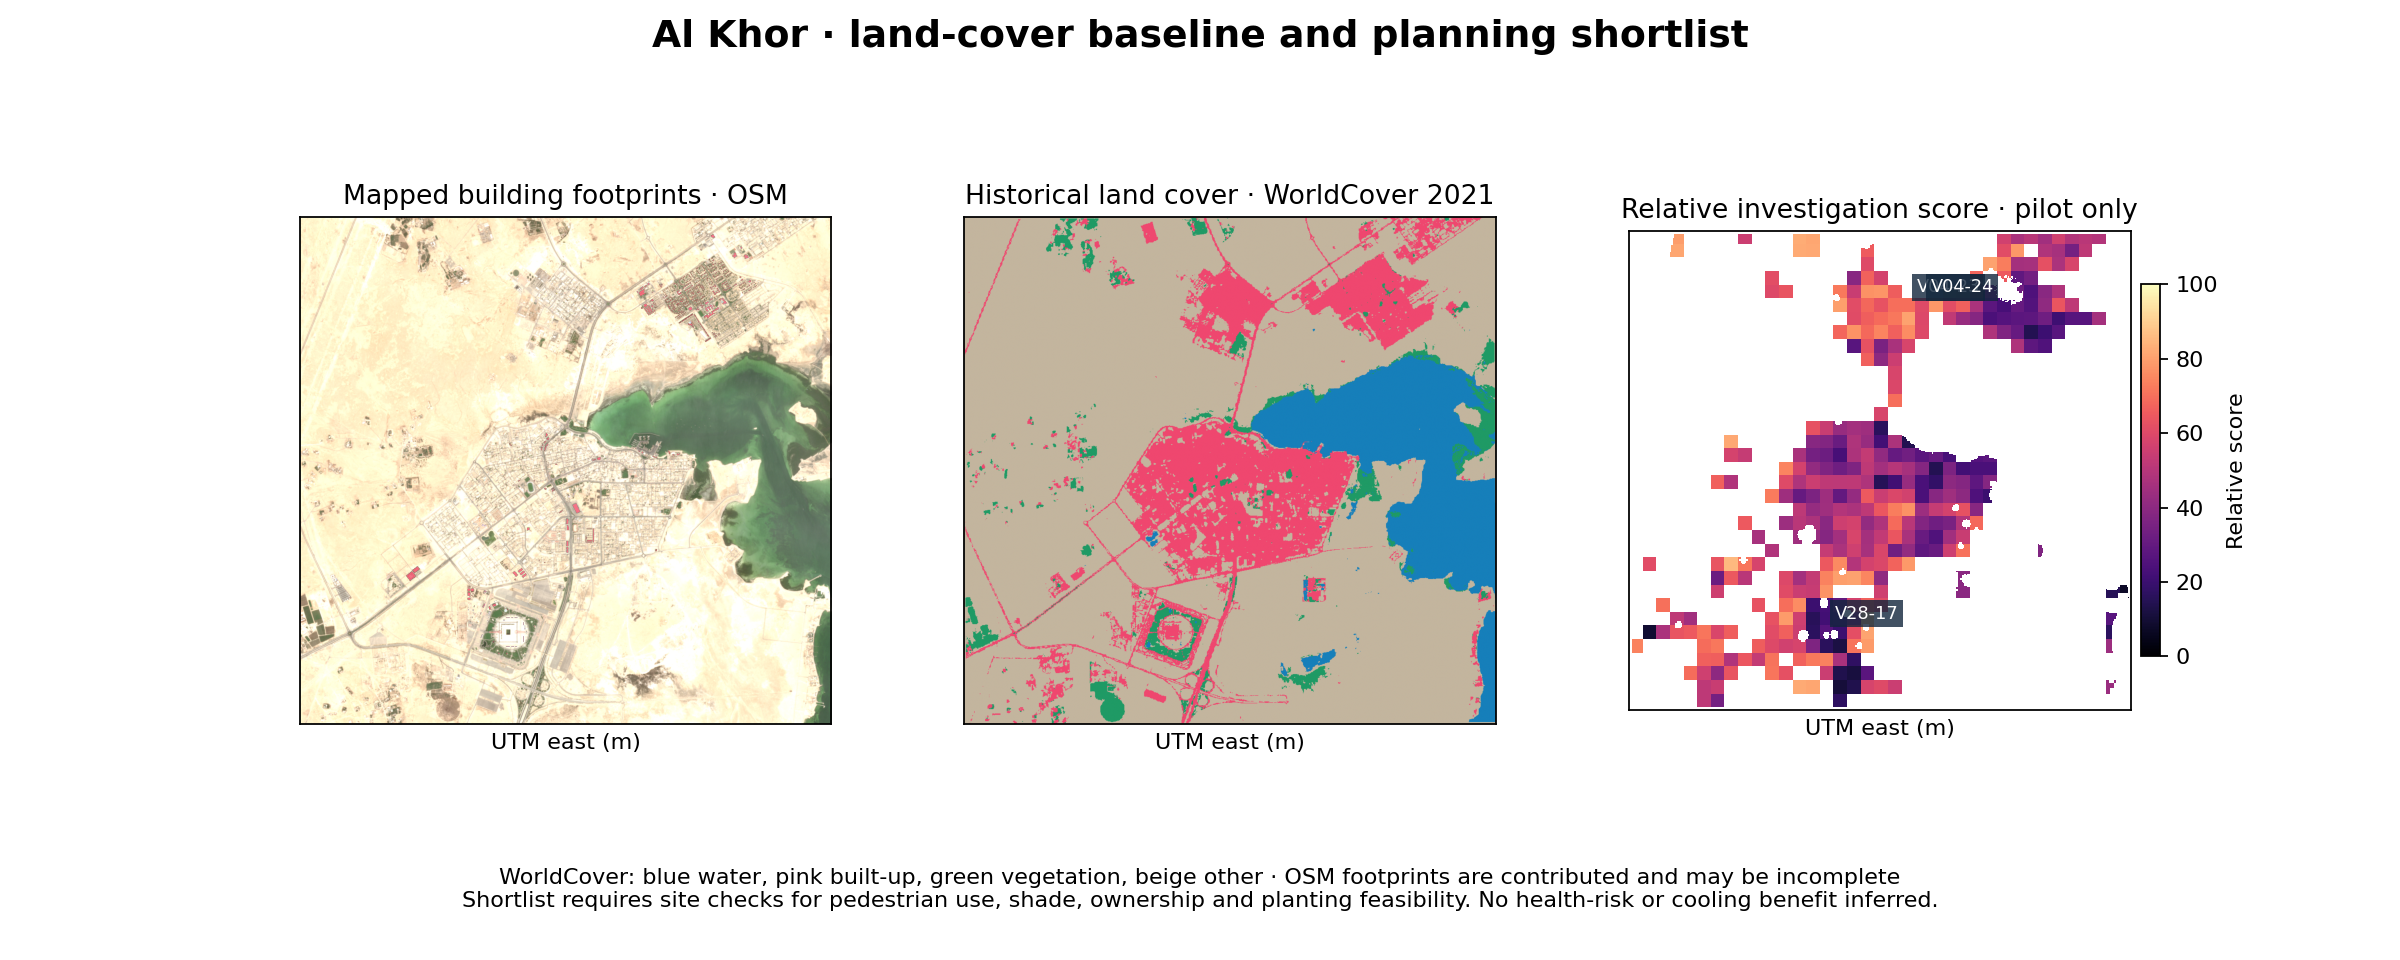

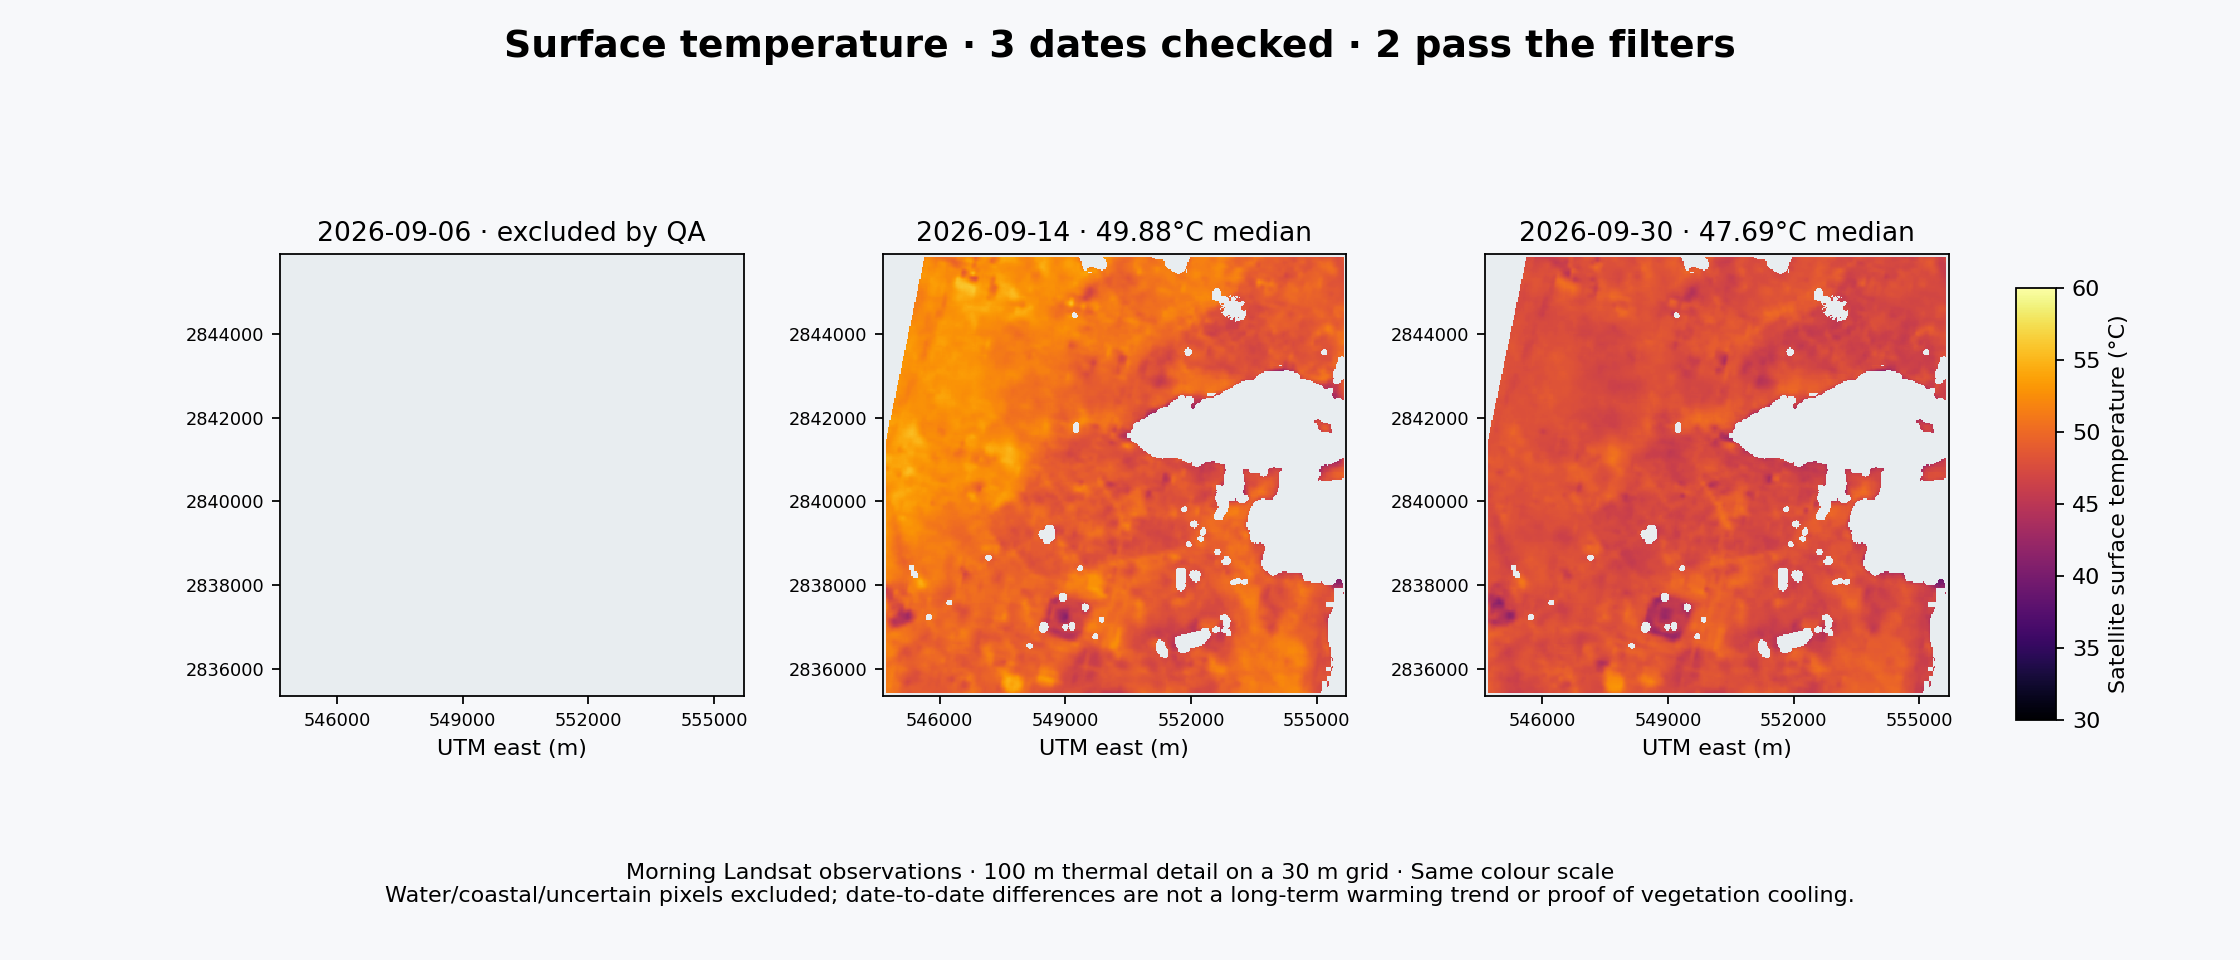

In [3]:
display(Image(filename=str(ROOT / "results/planning-map.png")))
display(Image(filename=str(ROOT / "results/multidate-temperature.png")))

## Reference checks and sensitivity

Contributed OSM labels provide limited positive-reference checks, with human confirmation pending. They do not establish representative accuracy or thermal calibration. WorldCover uses some OSM auxiliary inputs.

Urban candidates require historical built-up share ≥10% OR mapped-building share ≥2% within observed support. This uncalibrated screen can miss unmapped or recently developed places; excluded desert/context cells remain in context-cells.csv. Thirteen settings test optical thresholds, buffers, QA, coverage, score weights and urban-screen cutoffs. The score combines 50% heat rank, 30% inverse greenery rank and 20% mapped-building rank. It is a site-investigation heuristic.

In [4]:
for check in planning["reference_checks"]:
    print(check)
for p in planning["top3"]:
    print(p["cell_id"], "rank range", p["scenario_best_rank"], "to", p["scenario_worst_rank"], "across", p["scenarios_eligible"], "settings")

{'reference_class': 'building', 'eligible_core_10m_pixels': 641, 'spaced_samples': 30, 'screened_water_percent': 0.0, 'ndvi_green_percent': 0.0, 'worldcover_built_up_percent': 83.3, 'retained_thermal_sample_count': 30}
{'reference_class': 'water', 'eligible_core_10m_pixels': 26959, 'spaced_samples': 30, 'screened_water_percent': 0.0, 'ndvi_green_percent': 0.0, 'worldcover_built_up_percent': 6.7, 'retained_thermal_sample_count': 29}
{'reference_class': 'grass', 'eligible_core_10m_pixels': 612, 'spaced_samples': 25, 'screened_water_percent': 0.0, 'ndvi_green_percent': 96.0, 'worldcover_built_up_percent': 4.0, 'retained_thermal_sample_count': 20}
{'reference_class': 'coastal_water', 'eligible_core_10m_pixels': None, 'spaced_samples': 30, 'screened_water_percent': 66.7, 'ndvi_green_percent': 26.7, 'worldcover_built_up_percent': None, 'retained_thermal_sample_count': 0}
V04-23 rank range 1 to 14 across 13 settings
V28-17 rank range 1 to 23 across 13 settings
V04-24 rank range 2 to 34 across

## Numerical checks

The next cell verifies source QA, temperature scaling, matching grid support, urban-screen eligibility and map counts. Product uncertainty is not a confidence interval. Three morning scenes cannot establish long-term change, human exposure or causal vegetation cooling.

In [5]:
verification = runpy.run_path(str(ROOT / "src/verify.py"))
print("Scientific and file checks passed.")

{"samples": 104931, "cells": 373, "source_checks": 115, "status": "pass"}
Scientific and file checks passed.


## Outputs and interpretation

Results are under `results/`. `planning-cells.csv` and GeoJSON contain cell values, ranks, observed coverage and sensitivity ranges. `reference-samples.csv` contains explicit source references and pending human confirmation fields. `app/assets/` holds regenerated map data and raster layers.

Before intervention, inspect pedestrian use, current shade, ownership, planting feasibility and the age/completeness of mapped buildings. VHR segmentation, paved-surface separation, population and independent thermal validation are future extensions. See README.md for licences, reproduction and submission readiness.